# Hierarchical Classifier (HC) — Unified Training Pipeline
## ARCUNet → SLRC → HC  |  Target: 90%+ Sub-class Accuracy

### What's in this notebook (merged best-of-both)
| Feature | Source |
|---|---|
| System / GPU pre-flight check | HC.ipynb |
| AMP (float16) + channels_last + OOM recovery | HC.ipynb |
| RAM guard + clear_memory utility | HC.ipynb |
| Hybrid in-memory dataset balancing | HC_improved |
| WeightedRandomSampler (train loader) | HC_improved |
| SEBlock channel attention in main head | HC_improved |
| LayerNorm heads + pretrained backbone | HC_improved |
| Differential LR (backbone × 0.1) | HC_improved |
| AsymmetricFocalLoss with per-class alpha | HC_improved |
| OneCycleLR with correct div_factors | HC_improved |
| MixUp + CutMix per batch | both |
| 7-view TTA (loader-based) | HC_improved |
| SLRC / ARCUNet pipeline integration | HC.ipynb |
| Full end-to-end classify_image helper | HC.ipynb |

**Run cells top-to-bottom. Only `CONFIG` needs editing.**

In [57]:
# ── PACKAGE CHECK ────────────────────────────────────────────────────────────
import subprocess, sys

_pkgs = ["timm==0.9.2", "scikit-learn", "seaborn", "torchvision",
         "torch", "pandas", "numpy", "tqdm", "Pillow", "psutil"]
for p in _pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p],
                   capture_output=True)
print("✓ All packages ready")

✓ All packages ready


In [58]:
# ── SYSTEM PRE-FLIGHT ────────────────────────────────────────────────────────
import psutil, torch

def quick_system_check():
    ram = psutil.virtual_memory()
    print(f"RAM   : {ram.available/1e9:.1f} GB free / {ram.total/1e9:.1f} GB  ({ram.percent:.1f}% used)")
    if ram.percent > 80:
        print("  ⚠  RAM > 80% — close other apps before training")

    if torch.cuda.is_available():
        fm, tm = torch.cuda.mem_get_info()
        print(f"GPU   : {torch.cuda.get_device_name(0)}")
        print(f"VRAM  : {fm/1e9:.1f} GB free / {tm/1e9:.1f} GB total")
        if tm/1e9 < 4:
            print("  ⚠  < 4 GB VRAM — use batch_size=4, model_type='s1'")
    else:
        print("GPU   : ✗ Not available — CPU-only training will be slow")

    cpu = psutil.cpu_count(logical=False)
    print(f"CPU   : {cpu} physical cores  |  {psutil.cpu_percent(0.3):.1f}% used")
    print("\n✓ System check complete")

quick_system_check()

RAM   : 53.9 GB free / 67.1 GB  (19.6% used)
GPU   : NVIDIA GeForce RTX 4070 SUPER
VRAM  : 9.3 GB free / 12.4 GB total
CPU   : 12 physical cores  |  16.1% used

✓ System check complete


In [59]:
import os, sys, gc, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from tqdm import tqdm
import psutil

warnings.filterwarnings('ignore')

# EfficientFormerV2 — file must be at: ./EfficientFormer-main/models/efficientformer_v2.py
import importlib.util
spec = importlib.util.spec_from_file_location("efficientformer_v2", "/home/vjti-comp/Desktop/Final Project Code/HC/EfficientFormer-main/models/efficientformer_v2.py")
eff_module = importlib.util.module_from_spec(spec)
sys.modules["efficientformer_v2"] = eff_module
spec.loader.exec_module(eff_module)
efficientformerv2_s2 = eff_module.efficientformerv2_s2
efficientformerv2_s1 = eff_module.efficientformerv2_s1

print(f"✓ Imports OK  |  PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ Imports OK  |  PyTorch 2.10.0+cu128  |  CUDA: True
  GPU: NVIDIA GeForce RTX 4070 SUPER


In [60]:
# ── MEMORY HELPERS ───────────────────────────────────────────────────────────
def check_memory(verbose=False):
    ram = psutil.virtual_memory()
    gpu_gb = 0.0
    if torch.cuda.is_available():
        gpu_gb = torch.cuda.memory_allocated() / 1e9
        if verbose:
            print(f"  GPU  : {gpu_gb:.2f} GB alloc / {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")
    if verbose:
        print(f"  RAM  : {ram.used/1e9:.2f} / {ram.total/1e9:.2f} GB  ({ram.percent:.1f}%)")
    if ram.percent > 85 and verbose:
        print("  ⚠  RAM > 85% — risk of system freeze!")
    return {'ram_percent': ram.percent, 'gpu_gb': gpu_gb}

def clear_memory(verbose=False):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if verbose:
        print("✓ Memory cleared")

check_memory(verbose=True)

  GPU  : 0.39 GB alloc / 2.29 GB reserved
  RAM  : 13.17 / 67.12 GB  (19.6%)


{'ram_percent': 19.6, 'gpu_gb': 0.394953216}

In [61]:
# ── CONFIGURATION  — only edit here ──────────────────────────────────────────
_DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CONFIG = {
    # ── Paths ─────────────────────────────────────────────────────────────
    'csv_path'         : 'dataset_complete.csv',       # raw full dataset CSV
    'data_root'        : '/data/Stagewise Dataset/HC/',
    'save_dir'         : './checkpoints',
    'ckpt_name'        : 'hc_best_v2.pt',  # v2: new training with improved hyperparams

    # ── ARCUNet / SLRC (optional — leave use_pipeline=False if not available)
    'arcunet_ckpt'     : '../ARCUNEet/checkpoints/ARCUNet_best_model.pt',
    'use_pipeline'     : False,
    'seg_threshold'    : 0.5,
    'roi_padding'      : 10,

    # ── Model ────────────────────────────────────────────────────────────
    'model_type'       : 's2',       # 's1' (6 M, fast) | 's2' (12 M, accurate)
    'pretrained'       : True,       # ImageNet weights via timm
    'img_size'         : 224,

    # ── Dataset balancing ────────────────────────────────────────────────
    'target_per_class' : 5000,       # hybrid-balance target per sub-class
    'min_class_size'   : 300,        # drop sub-classes smaller than this

    # ── Splits ───────────────────────────────────────────────────────────
    'val_split'        : 0.15,
    'test_split'       : 0.10,

    # ── Training ─────────────────────────────────────────────────────────
    'epochs'           : 100,        # extended from 60 for better convergence
    'batch_size'       : 24,         # increased from 16 (reduce to 12 if GPU OOM)
    'lr'               : 1e-4,       # lowered from 3e-4 for stability
    'weight_decay'     : 1e-2,
    'min_lr'           : 1e-7,       # lowered from 1e-6
    'warmup_epochs'    : 8,          # increased from 5 for slower ramp-up
    'grad_clip'        : 1.0,
    'patience'         : 15,

    # ── Loss ─────────────────────────────────────────────────────────────
    'main_loss_w'      : 0.15,       # lowered from 0.25
    'sub_loss_w'       : 1.85,       # increased from 1.75 (penalize sub-class errors more)
    'focal_gamma'      : 2.5,        # increased from 2.0 (focus harder on difficult samples)
    'label_smoothing'  : 0.1,

    # ── Augmentation ─────────────────────────────────────────────────────
    'mixup_alpha'      : 0.5,        # increased from 0.4
    'cutmix_alpha'     : 1.2,        # increased from 1.0
    'mixup_prob'       : 0.7,        # increased from 0.5 (more mixing per batch)

    # ── Loader ───────────────────────────────────────────────────────────
    'num_workers'      : 4,
    'pin_memory'       : True,

    # ── Misc ─────────────────────────────────────────────────────────────
    'seed'             : 42,
    'device'           : _DEV,
}

os.makedirs(CONFIG['save_dir'], exist_ok=True)

SEED = CONFIG['seed']
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('medium')  # Ampere speed-up

USE_AMP = CONFIG['device'].type == 'cuda'

print(f"Device  : {CONFIG['device']}  |  AMP: {USE_AMP}")
print(f"Model   : EfficientFormerV2-{CONFIG['model_type'].upper()}  |  pretrained: {CONFIG['pretrained']}")
print(f"Epochs  : {CONFIG['epochs']}  |  Batch: {CONFIG['batch_size']}  |  LR: {CONFIG['lr']}")
print(f"Balance : {CONFIG['target_per_class']} imgs/class  |  min class: {CONFIG['min_class_size']}")

Device  : cuda  |  AMP: True
Model   : EfficientFormerV2-S2  |  pretrained: True
Epochs  : 100  |  Batch: 24  |  LR: 0.0001
Balance : 5000 imgs/class  |  min class: 300


In [62]:
# ── LOAD CSV + HYBRID IN-MEMORY BALANCING ────────────────────────────────────
df_raw = pd.read_csv(CONFIG['csv_path'])
print(f"Raw dataset : {len(df_raw):,} samples")
print(f"\nRaw sub-class distribution:")
print(df_raw['sub_class'].value_counts().to_string())

# Drop classes that are too small to generalise from
counts  = df_raw['sub_class'].value_counts()
valid   = counts[counts >= CONFIG['min_class_size']].index
dropped = set(df_raw['sub_class'].unique()) - set(valid)
if dropped:
    print(f"\n⚠ Dropped (< {CONFIG['min_class_size']} samples): {dropped}")
df = df_raw[df_raw['sub_class'].isin(valid)].copy()

# Hybrid balance: undersample large classes, oversample small ones
TARGET   = CONFIG['target_per_class']
balanced = []
for cls, grp in df.groupby('sub_class'):
    n = len(grp)
    if n >= TARGET:
        balanced.append(grp.sample(n=TARGET, random_state=SEED))
    else:
        reps = TARGET // n
        rem  = TARGET  % n
        balanced.append(pd.concat(
            [grp] * reps + [grp.sample(n=rem, random_state=SEED)],
            ignore_index=True))

df_bal = (pd.concat(balanced, ignore_index=True)
            .sample(frac=1, random_state=SEED)
            .reset_index(drop=True))

print(f"\n✓ Balanced: {len(df_bal):,} samples  ({TARGET} per sub-class)")
print(df_bal['main_class'].value_counts().to_string())

# Class index maps — consistent names used throughout
main_classes = sorted(df_bal['main_class'].unique())
sub_classes  = sorted(df_bal['sub_class'].unique())
main2idx     = {c: i for i, c in enumerate(main_classes)}
sub2idx      = {c: i for i, c in enumerate(sub_classes)}
idx2main     = {i: c for c, i in main2idx.items()}
idx2sub      = {i: c for c, i in sub2idx.items()}
NUM_MAIN     = len(main_classes)
NUM_SUB      = len(sub_classes)

# sub_idx → main_idx lookup tensor (used for hierarchy validation)
sub_to_main = torch.zeros(NUM_SUB, dtype=torch.long)
for sname, si in sub2idx.items():
    sub_to_main[si] = main2idx[df_bal[df_bal['sub_class']==sname].iloc[0]['main_class']]
sub_to_main = sub_to_main.to(CONFIG['device'])

print(f"\nMain classes ({NUM_MAIN}): {main_classes}")
print(f"Sub  classes ({NUM_SUB}): {sub_classes}")

Raw dataset : 43,242 samples

Raw sub-class distribution:
sub_class
melanocytic_nevus          23107
melanoma                    7154
basal_cell_carcinoma        4920
seborrheic_keratosis        4622
actinic_keratosis           1619
squamous_cell_carcinoma      793
vascular_lesion              537
Dermatifibroma               490

✓ Balanced: 40,000 samples  (5000 per sub-class)
main_class
malignant    20000
benign       20000

Main classes (2): ['benign', 'malignant']
Sub  classes (8): ['Dermatifibroma', 'actinic_keratosis', 'basal_cell_carcinoma', 'melanocytic_nevus', 'melanoma', 'seborrheic_keratosis', 'squamous_cell_carcinoma', 'vascular_lesion']


In [63]:
# ── STRATIFIED TRAIN / VAL / TEST SPLIT ─────────────────────────────────────
train_df, temp_df = train_test_split(
    df_bal, test_size=CONFIG['val_split']+CONFIG['test_split'],
    stratify=df_bal['sub_class'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df,
    test_size=CONFIG['test_split']/(CONFIG['val_split']+CONFIG['test_split']),
    stratify=temp_df['sub_class'], random_state=SEED)

print(f"Train : {len(train_df):>6,}")
print(f"Val   : {len(val_df):>6,}")
print(f"Test  : {len(test_df):>6,}")

Train : 30,000
Val   :  6,000
Test  :  4,000


In [64]:
# ── AUGMENTATION PIPELINES ───────────────────────────────────────────────────
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]
SZ    = CONFIG['img_size']

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(SZ, scale=(0.5, 1.0), ratio=(0.7, 1.4)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(45),         # increased from 30
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.RandAugment(num_ops=3, magnitude=15),  # increased from (2,10)
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
    transforms.RandomAutocontrast(p=0.4),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.4),
    transforms.RandomEqualize(p=0.3),
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 2.5))], p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3)),  # adds subtle blur
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.25), ratio=(0.3, 3.3), value='random'),
])

val_transform = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])
test_transform = val_transform

print("✓ Transforms defined")
print("  Train : RandomResizedCrop → RandAugment → ColorJitter → Erasing + MixUp/CutMix in loop")
print("  Val/Test : Resize + Normalise")

✓ Transforms defined
  Train : RandomResizedCrop → RandAugment → ColorJitter → Erasing + MixUp/CutMix in loop
  Val/Test : Resize + Normalise


In [65]:
# ── DATASET CLASS + DATALOADERS ──────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """
    On-demand image loader. No ROI pre-caching to avoid RAM overflow.
    If `pipeline` is set, images are processed through ARCUNet → SLRC first.
    """
    def __init__(self, df, data_root, main2idx, sub2idx,
                 transform=None, pipeline=None):
        self.df        = df.reset_index(drop=True)
        self.data_root = data_root
        self.main2idx  = main2idx
        self.sub2idx   = sub2idx
        self.transform = transform
        self.pipeline  = pipeline

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.data_root, row['image_path'])
        try:
            if self.pipeline is not None:
                roi = self.pipeline.process_image(
                    path, output_size=(SZ, SZ), return_intermediate=False)
                img = Image.fromarray(roi.astype('uint8'))
            else:
                img = Image.open(path).convert('RGB')
        except Exception as e:
            tqdm.write(f"  ⚠ Load error [{path}]: {e}")
            img = Image.new('RGB', (SZ, SZ), color=(0, 0, 0))

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return {
            'image'      : img,
            'main_class' : torch.tensor(self.main2idx[row['main_class']], dtype=torch.long),
            'sub_class'  : torch.tensor(self.sub2idx [row['sub_class']],  dtype=torch.long),
        }


# Optional SLRC pipeline init
pipeline = None
if CONFIG['use_pipeline'] and os.path.exists(CONFIG['arcunet_ckpt']):
    try:
        sys.path.insert(0, '../Main files')
        from pipeline_functions import SkinLesionPipeline
        pipeline = SkinLesionPipeline(CONFIG['arcunet_ckpt'], device=CONFIG['device'])
        print(f"✓ SLRC pipeline loaded  ({CONFIG['arcunet_ckpt']})")
    except Exception as e:
        print(f"⚠ Pipeline failed: {e} — training without SLRC")

train_ds = SkinLesionDataset(train_df, CONFIG['data_root'], main2idx, sub2idx,
                              transform=train_transform, pipeline=pipeline)
val_ds   = SkinLesionDataset(val_df,   CONFIG['data_root'], main2idx, sub2idx,
                              transform=val_transform,   pipeline=pipeline)
test_ds  = SkinLesionDataset(test_df,  CONFIG['data_root'], main2idx, sub2idx,
                              transform=test_transform,  pipeline=pipeline)

# WeightedRandomSampler: extra imbalance guard even after hybrid balancing
sub_counts_train = train_df['sub_class'].value_counts().to_dict()
sample_weights   = [1.0 / sub_counts_train[r['sub_class']]
                    for _, r in train_df.iterrows()]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds),
                                replacement=True)

NW = CONFIG['num_workers']
PM = CONFIG['pin_memory']
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          sampler=sampler, num_workers=NW,
                          pin_memory=PM, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=NW, pin_memory=PM)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=NW, pin_memory=PM)

print(f"✓ DataLoaders  Train:{len(train_loader)} | Val:{len(val_loader)} | Test:{len(test_loader)} batches")
print(f"  WeightedRandomSampler active on train loader")

✓ DataLoaders  Train:1250 | Val:250 | Test:167 batches
  WeightedRandomSampler active on train loader


In [66]:
# ── MODEL: CONDITIONAL HIERARCHICAL CLASSIFIER ───────────────────────────────
#
# Architecture:
#   EfficientFormerV2 backbone (pretrained ImageNet)
#   → SEBlock channel attention
#   → main_head  (benign / malignant)
#   → sub_head   (backbone_feat + main_logits.detach() → sub-type)
#
# The conditional sub-head explicitly sees which main class is predicted,
# encoding the biological hierarchy directly into the computation.

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (1-D for feature vectors)."""    
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):          # x: (B, C)
        return x * self.fc(x)


class HierarchicalClassifier(nn.Module):
    def __init__(self, num_main, num_sub, model_type='s2', pretrained=True):
        super().__init__()

        # Backbone — hard-coded feature dims match EfficientFormerV2 paper
        if model_type == 's2':
            self.backbone = efficientformerv2_s2(pretrained=pretrained)
            feat_dim = 288
        else:
            self.backbone = efficientformerv2_s1(pretrained=pretrained)
            feat_dim = 224

        self.backbone.head = nn.Identity()
        if hasattr(self.backbone, 'dist_head'):
            self.backbone.dist_head = nn.Identity()
        self.feat_dim = feat_dim

        # Main head: SE attention → 2-layer MLP
        self.main_head = nn.Sequential(
            SEBlock(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, num_main),
        )

        # Sub head: conditional on main logits (detached gradient)
        sub_in = feat_dim + num_main
        self.sub_head = nn.Sequential(
            nn.Linear(sub_in, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, num_sub),
        )

    def forward(self, x):
        feats = self.backbone(x)
        if isinstance(feats, (list, tuple)):
            feats = feats[0]
        main_logits = self.main_head(feats)
        sub_logits  = self.sub_head(torch.cat([feats, main_logits.detach()], dim=1))
        return main_logits, sub_logits


model = HierarchicalClassifier(
    num_main   = NUM_MAIN,
    num_sub    = NUM_SUB,
    model_type = CONFIG['model_type'],
    pretrained = CONFIG['pretrained'],
).to(CONFIG['device'])

if CONFIG['device'].type == 'cuda':
    model = model.to(memory_format=torch.channels_last)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ HierarchicalClassifier (EfficientFormerV2-{CONFIG['model_type'].upper()})")
print(f"  Total params    : {total:,}")
print(f"  Trainable params: {trainable:,}")
print(f"  Feature dim     : {model.feat_dim}")
print(f"  Conditional sub-head input dim: {model.feat_dim + NUM_MAIN}")

✓ HierarchicalClassifier (EfficientFormerV2-S2)
  Total params    : 12,501,402
  Trainable params: 12,501,402
  Feature dim     : 288
  Conditional sub-head input dim: 290


In [67]:
# ── LOSS, OPTIMIZER, SCHEDULER ───────────────────────────────────────────────

class AsymmetricFocalLoss(nn.Module):
    """
    Focal Loss with per-class alpha (inverse-frequency) weighting
    and label smoothing.  Works for any number of classes.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha    # (C,) tensor or None
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        C = logits.size(1)
        with torch.no_grad():
            smooth = torch.full_like(logits, self.label_smoothing / (C - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        log_p   = F.log_softmax(logits, dim=1)
        ce      = -(smooth * log_p).sum(dim=1)                    # (B,)
        pt      = log_p.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        loss    = ((1 - pt) ** self.gamma) * ce                   # (B,)
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


def make_class_weights(df_split, col, class_list, device):
    """Normalised inverse-frequency class weights."""    
    counts = df_split[col].value_counts()
    total  = len(df_split)
    w = torch.tensor(
        [total / (len(class_list) * counts.get(c, 1)) for c in class_list],
        dtype=torch.float32).to(device)
    return w / w.sum() * len(class_list)   # normalise so mean ≈ 1


main_alpha = make_class_weights(train_df, 'main_class', main_classes, CONFIG['device'])
sub_alpha  = make_class_weights(train_df, 'sub_class',  sub_classes,  CONFIG['device'])

criterion_main = AsymmetricFocalLoss(alpha=main_alpha, gamma=1.0,
                                     label_smoothing=CONFIG['label_smoothing'])
criterion_sub  = AsymmetricFocalLoss(alpha=sub_alpha,  gamma=CONFIG['focal_gamma'],
                                     label_smoothing=CONFIG['label_smoothing'])

# Differential LR: backbone gets 10× lower LR than the newly-initialised heads
backbone_params = list(model.backbone.parameters())
head_params     = list(model.main_head.parameters()) + list(model.sub_head.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': CONFIG['lr'] * 0.1},
    {'params': head_params,     'lr': CONFIG['lr']},
], weight_decay=CONFIG['weight_decay'])

# OneCycleLR: linear warmup then cosine decay — one smooth schedule
total_steps = CONFIG['epochs'] * len(train_loader)
scheduler   = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr           = [CONFIG['lr'] * 0.1, CONFIG['lr']],
    total_steps      = total_steps,
    pct_start        = CONFIG['warmup_epochs'] / CONFIG['epochs'],
    anneal_strategy  = 'cos',
    div_factor       = 10.0,
    final_div_factor = CONFIG['lr'] / CONFIG['min_lr'],
)

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print("✓ AsymmetricFocalLoss (per-class alpha)")
print(f"  main alpha: {main_alpha.cpu().numpy().round(3)}")
print(f"  sub  alpha: {sub_alpha.cpu().numpy().round(3)}")
print("✓ AdamW (backbone lr×0.1 / head lr full)")
print("✓ OneCycleLR with warmup")
print(f"✓ AMP GradScaler enabled: {USE_AMP}")

✓ AsymmetricFocalLoss (per-class alpha)
  main alpha: [1. 1.]
  sub  alpha: [1. 1. 1. 1. 1. 1. 1. 1.]
✓ AdamW (backbone lr×0.1 / head lr full)
✓ OneCycleLR with warmup
✓ AMP GradScaler enabled: True


In [68]:
# ── MIXUP / CUTMIX HELPERS ───────────────────────────────────────────────────

def mixup_batch(images, main_lbl, sub_lbl, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, main_lbl, sub_lbl, main_lbl[idx], sub_lbl[idx], lam

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cw = int(W * np.sqrt(1 - lam));  ch = int(H * np.sqrt(1 - lam))
    cx = np.random.randint(W);        cy = np.random.randint(H)
    x1 = np.clip(cx - cw // 2, 0, W); y1 = np.clip(cy - ch // 2, 0, H)
    x2 = np.clip(cx + cw // 2, 0, W); y2 = np.clip(cy + ch // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_batch(images, main_lbl, sub_lbl, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    x1, y1, x2, y2 = rand_bbox(images.size(), lam)
    images = images.clone()
    images[:, :, x1:x2, y1:y2] = images[idx, :, x1:x2, y1:y2]
    lam_actual = 1 - (x2-x1)*(y2-y1) / (images.size(-1)*images.size(-2))
    return images, main_lbl, sub_lbl, main_lbl[idx], sub_lbl[idx], lam_actual

def mixed_loss(criterion, logits, ya, yb, lam):
    return lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb)

print("✓ MixUp / CutMix helpers defined")

✓ MixUp / CutMix helpers defined


In [69]:
# ── TRAINING & EVALUATION FUNCTIONS ──────────────────────────────────────────

def train_epoch(model, loader, optimizer, scheduler, scaler,
                criterion_main, criterion_sub, cfg):
    model.train()
    total_m = total_s = 0.0
    device  = cfg['device']

    pbar = tqdm(loader, desc="Train", leave=False)
    for batch_idx, batch in enumerate(pbar):
        images    = batch['image'].to(device, non_blocking=True)
        main_lbl  = batch['main_class'].to(device, non_blocking=True)
        sub_lbl   = batch['sub_class'].to(device, non_blocking=True)

        if device.type == 'cuda':
            images = images.to(memory_format=torch.channels_last)

        # MixUp / CutMix
        use_mix = np.random.random() < cfg['mixup_prob']
        m_b = s_b = lam = None
        if use_mix:
            if np.random.random() < 0.5:
                images, main_lbl, sub_lbl, m_b, s_b, lam = mixup_batch(
                    images, main_lbl, sub_lbl, cfg['mixup_alpha'])
            else:
                images, main_lbl, sub_lbl, m_b, s_b, lam = cutmix_batch(
                    images, main_lbl, sub_lbl, cfg['cutmix_alpha'])

        optimizer.zero_grad(set_to_none=True)

        try:
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                ml, sl = model(images)
                if use_mix and lam is not None:
                    m_loss = mixed_loss(criterion_main, ml, main_lbl, m_b, lam)
                    s_loss = mixed_loss(criterion_sub,  sl, sub_lbl,  s_b, lam)
                else:
                    m_loss = criterion_main(ml, main_lbl)
                    s_loss = criterion_sub(sl,  sub_lbl)
                loss = cfg['main_loss_w'] * m_loss + cfg['sub_loss_w'] * s_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_m += m_loss.item()
            total_s += s_loss.item()
            pbar.set_postfix(m=f'{m_loss.item():.3f}', s=f'{s_loss.item():.3f}',
                             lr=f'{optimizer.param_groups[-1]["lr"]:.1e}')

        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
                tqdm.write(f"  [OOM] batch {batch_idx} skipped")
                continue
            raise

        # Periodic RAM guard
        if batch_idx % 200 == 0 and batch_idx > 0:
            if check_memory()['ram_percent'] > 90:
                tqdm.write("  ⚠ RAM > 90% — clearing cache")
                clear_memory()

    n = len(loader)
    return total_m / n, total_s / n


@torch.no_grad()
def evaluate(model, loader, criterion_main, criterion_sub, cfg,
             verbose=False):
    model.eval()
    device     = cfg['device']
    total_loss = 0.0
    m_preds, m_tgts, s_preds, s_tgts = [], [], [], []

    for batch in tqdm(loader, desc="Eval ", leave=False):
        images   = batch['image'].to(device, non_blocking=True)
        main_lbl = batch['main_class'].to(device, non_blocking=True)
        sub_lbl  = batch['sub_class'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            ml, sl = model(images)
            loss   = (cfg['main_loss_w'] * criterion_main(ml, main_lbl) +
                      cfg['sub_loss_w']  * criterion_sub(sl,  sub_lbl))
        total_loss += loss.item()

        m_preds.extend(ml.argmax(1).cpu().tolist())
        m_tgts .extend(main_lbl.cpu().tolist())
        s_preds.extend(sl.argmax(1).cpu().tolist())
        s_tgts .extend(sub_lbl.cpu().tolist())

    m_preds = np.array(m_preds); m_tgts = np.array(m_tgts)
    s_preds = np.array(s_preds); s_tgts = np.array(s_tgts)

    main_acc = accuracy_score(m_tgts, m_preds)
    sub_acc  = accuracy_score(s_tgts, s_preds)
    main_f1  = f1_score(m_tgts, m_preds, average='weighted')
    sub_f1   = f1_score(s_tgts, s_preds, average='weighted')

    if verbose:
        print("  Per-class sub accuracy (3 weakest):")
        per = [(idx2sub[ci], (s_preds[s_tgts==ci] == s_tgts[s_tgts==ci]).mean(),
                (s_tgts==ci).sum())
               for ci in range(NUM_SUB) if (s_tgts==ci).any()]
        for name, acc, n in sorted(per, key=lambda x: x[1])[:3]:
            print(f"    {name:<35} {acc:.3f}  ({n} samples)  ⚠")

    return total_loss / len(loader), main_acc, sub_acc, main_f1, sub_f1

print("✓ train_epoch + evaluate defined (AMP, MixUp/CutMix, OOM recovery)")

✓ train_epoch + evaluate defined (AMP, MixUp/CutMix, OOM recovery)


In [70]:
# ── TRAINING LOOP ────────────────────────────────────────────────────────────
history = {k: [] for k in
           ['train_m_loss', 'train_s_loss', 'val_loss',
            'val_main_acc', 'val_sub_acc', 'val_main_f1', 'val_sub_f1', 'lr']}

best_sub_acc     = 0.0
best_epoch       = 0
patience_counter = 0
CKPT             = os.path.join(CONFIG['save_dir'], CONFIG['ckpt_name'])

print("=" * 72)
print(f"TRAINING  {CONFIG['epochs']} epochs  |  target: 90%+ sub-class accuracy")
print("=" * 72)

for epoch in range(1, CONFIG['epochs'] + 1):
    verbose_epoch = (epoch % 5 == 0) or (epoch == 1)

    tm, ts = train_epoch(model, train_loader, optimizer, scheduler, scaler,
                         criterion_main, criterion_sub, CONFIG)

    val_loss, val_main_acc, val_sub_acc, val_main_f1, val_sub_f1 = evaluate(
        model, val_loader, criterion_main, criterion_sub, CONFIG,
        verbose=verbose_epoch)

    lr_now = optimizer.param_groups[-1]['lr']

    for k, v in zip(
        ['train_m_loss','train_s_loss','val_loss',
         'val_main_acc','val_sub_acc','val_main_f1','val_sub_f1','lr'],
        [tm, ts, val_loss, val_main_acc, val_sub_acc, val_main_f1, val_sub_f1, lr_now]):
        history[k].append(v)

    flag = " 🎯 TARGET!" if val_sub_acc >= 0.90 else ""
    print(f"Ep {epoch:02d}/{CONFIG['epochs']}  "
          f"loss(m={tm:.3f} s={ts:.3f} val={val_loss:.3f})  "
          f"acc(main={val_main_acc:.3f} sub={val_sub_acc:.3f})  "
          f"f1(main={val_main_f1:.3f} sub={val_sub_f1:.3f})  "
          f"lr={lr_now:.2e}{flag}")

    if val_sub_acc > best_sub_acc:
        best_sub_acc = val_sub_acc
        best_epoch   = epoch
        patience_counter = 0
        torch.save({
            'epoch'       : epoch,
            'model_sd'    : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_sub_acc' : val_sub_acc,
            'val_main_acc': val_main_acc,
            'sub_classes' : sub_classes,
            'main_classes': main_classes,
            'config'      : {k: str(v) for k, v in CONFIG.items()},
        }, CKPT)
        print(f"  ✓ Saved best model  (sub_acc={best_sub_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(no improvement for {CONFIG['patience']} epochs)")
            break

    if epoch % 10 == 0:
        clear_memory()

print("\n" + "=" * 72)
print(f"DONE  |  Best sub-class accuracy: {best_sub_acc:.4f} ({best_sub_acc*100:.2f}%)  @ epoch {best_epoch}")
print("=" * 72)

TRAINING  100 epochs  |  target: 90%+ sub-class accuracy


  Per-class sub accuracy (3 weakest):
    seborrheic_keratosis                0.003  (750 samples)  ⚠
    melanoma                            0.083  (750 samples)  ⚠
    actinic_keratosis                   0.112  (750 samples)  ⚠
Ep 01/100  loss(m=0.368 s=1.532 val=2.734)  acc(main=0.582 sub=0.182)  f1(main=0.563 sub=0.160)  lr=1.34e-05
  ✓ Saved best model  (sub_acc=0.1822)


Ep 02/100  loss(m=0.357 s=1.515 val=2.714)  acc(main=0.569 sub=0.193)  f1(main=0.527 sub=0.147)  lr=2.32e-05
  ✓ Saved best model  (sub_acc=0.1930)


Ep 03/100  loss(m=0.351 s=1.500 val=2.700)  acc(main=0.575 sub=0.178)  f1(main=0.547 sub=0.123)  lr=3.78e-05


Ep 04/100  loss(m=0.349 s=1.490 val=2.715)  acc(main=0.520 sub=0.216)  f1(main=0.398 sub=0.194)  lr=5.50e-05
  ✓ Saved best model  (sub_acc=0.2157)


...

Ep 76/100  loss(m=0.320 s=1.294 val=1.864)  acc(main=0.732 sub=0.417)  f1(main=0.730 sub=0.398)  lr=1.59e-05


Ep 77/100  loss(m=0.321 s=1.303 val=1.833)  acc(main=0.726 sub=0.428)  f1(main=0.721 sub=0.419)  lr=1.47e-05


Ep 78/100  loss(m=0.319 s=1.295 val=1.872)  acc(main=0.734 sub=0.419)  f1(main=0.732 sub=0.404)  lr=1.35e-05


Ep 79/100  loss(m=0.320 s=1.296 val=1.875)  acc(main=0.724 sub=0.418)  f1(main=0.720 sub=0.404)  lr=1.23e-05


  Per-class sub accuracy (3 weakest):
    basal_cell_carcinoma                0.167  (750 samples)  ⚠
    Dermatifibroma                      0.217  (750 samples)  ⚠
    squamous_cell_carcinoma             0.232  (750 samples)  ⚠
Ep 80/100  loss(m=0.320 s=1.296 val=1.876)  acc(main=0.735 sub=0.420)  f1(main=0.734 sub=0.403)  lr=1.12e-05

Early stopping at epoch 80 (no improvement for 15 epochs)

DONE  |  Best sub-class accuracy: 0.4343 (43.43%)  @ epoch 65


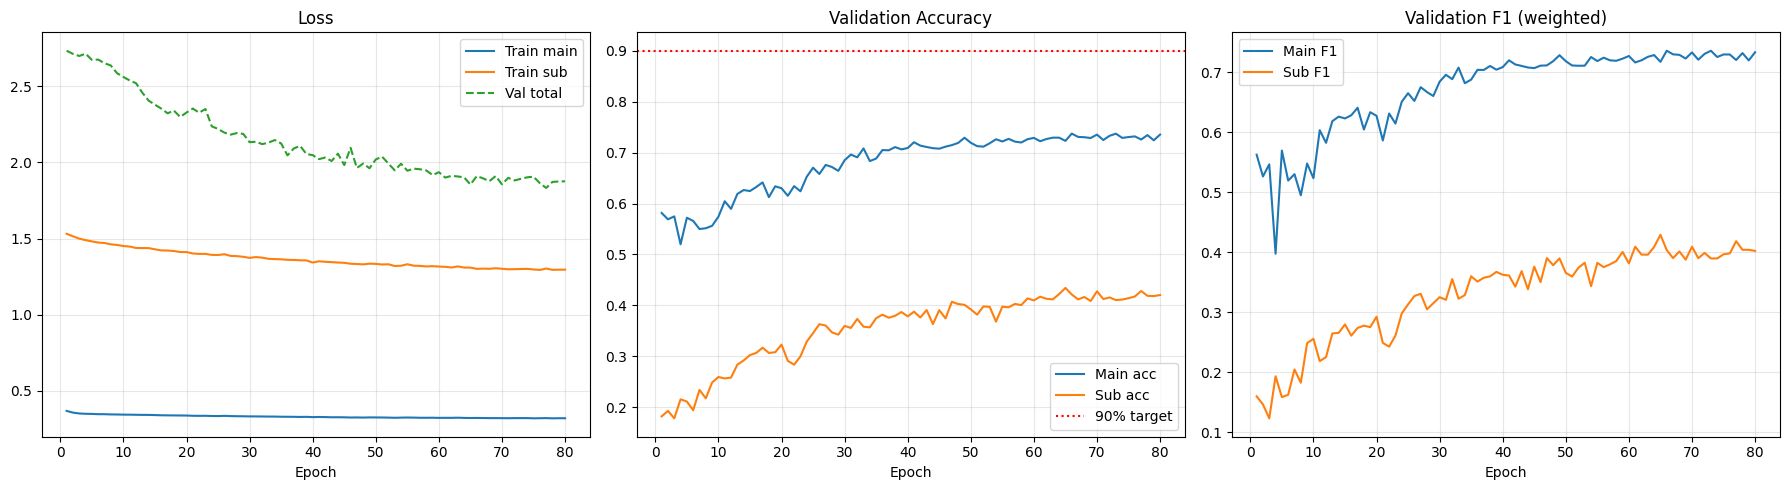

✓ Saved training_curves_v2.png


In [71]:
# ── TRAINING CURVES ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
E = range(1, len(history['train_m_loss']) + 1)

axes[0].plot(E, history['train_m_loss'], label='Train main')
axes[0].plot(E, history['train_s_loss'], label='Train sub')
axes[0].plot(E, history['val_loss'],     label='Val total', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(E, history['val_main_acc'], label='Main acc')
axes[1].plot(E, history['val_sub_acc'],  label='Sub acc')
axes[1].axhline(0.90, color='red', ls=':', lw=1.5, label='90% target')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(E, history['val_main_f1'], label='Main F1')
axes[2].plot(E, history['val_sub_f1'],  label='Sub F1')
axes[2].set_title('Validation F1 (weighted)'); axes[2].legend(); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved training_curves_v2.png")

In [72]:
# ── TEST SET EVALUATION ──────────────────────────────────────────────────────
ckpt = torch.load(CKPT, map_location=CONFIG['device'])
model.load_state_dict(ckpt['model_sd'])
print(f"✓ Loaded best checkpoint  epoch={ckpt['epoch']}  val_sub_acc={ckpt['val_sub_acc']:.4f}")

# Standard (fast) eval first
model.eval()
m_preds, m_tgts, s_preds, s_tgts = [], [], [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        images = batch['image'].to(CONFIG['device'], non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            ml, sl = model(images)
        m_preds.extend(ml.argmax(1).cpu().tolist())
        m_tgts .extend(batch['main_class'].tolist())
        s_preds.extend(sl.argmax(1).cpu().tolist())
        s_tgts .extend(batch['sub_class'].tolist())

m_preds = np.array(m_preds); m_tgts = np.array(m_tgts)
s_preds = np.array(s_preds); s_tgts = np.array(s_tgts)

print("\n" + "="*60)
print("MAIN CLASS — TEST RESULTS")
print("="*60)
print(classification_report([idx2main[i] for i in m_tgts],
                             [idx2main[i] for i in m_preds], digits=4))
print("\n" + "="*60)
print("SUB CLASS — TEST RESULTS")
print("="*60)
print(classification_report([idx2sub[i] for i in s_tgts],
                             [idx2sub[i] for i in s_preds], digits=4))

print(f"\nFinal test accuracy  →  main: {accuracy_score(m_tgts,m_preds):.4f}  "
      f"sub: {accuracy_score(s_tgts,s_preds):.4f}")

✓ Loaded best checkpoint  epoch=65  val_sub_acc=0.4343


Test: 100%|██████████| 167/167 [00:08<00:00, 18.77it/s]


MAIN CLASS — TEST RESULTS
              precision    recall  f1-score   support

      benign     0.8062    0.5740    0.6706      2000
   malignant     0.6693    0.8620    0.7535      2000

    accuracy                         0.7180      4000
   macro avg     0.7377    0.7180    0.7120      4000
weighted avg     0.7377    0.7180    0.7120      4000


SUB CLASS — TEST RESULTS
                         precision    recall  f1-score   support

         Dermatifibroma     0.5943    0.3340    0.4277       500
      actinic_keratosis     0.3443    0.6460    0.4492       500
   basal_cell_carcinoma     0.2575    0.3600    0.3003       500
      melanocytic_nevus     0.5341    0.6740    0.5959       500
               melanoma     0.5551    0.3020    0.3912       500
   seborrheic_keratosis     0.3314    0.2340    0.2743       500
squamous_cell_carcinoma     0.3592    0.2500    0.2948       500
        vascular_lesion     0.7218    0.6900    0.7055       500

               accuracy          

In [73]:
# ── TEST-TIME AUGMENTATION (TTA) EVALUATION — 7 views ───────────────────────
# TTA averages softmax probabilities over multiple augmented views of each image.
# Typical gain over single-pass: +0.5–2% accuracy.  Slower — grab a coffee ☕

_MEAN_T = [0.485, 0.456, 0.406]; _STD_T = [0.229, 0.224, 0.225]
tta_transforms = [
    transforms.Compose([transforms.Resize((SZ,SZ)),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
    transforms.Compose([transforms.Resize((SZ,SZ)), transforms.RandomHorizontalFlip(1.0),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
    transforms.Compose([transforms.Resize((SZ,SZ)), transforms.RandomVerticalFlip(1.0),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
    transforms.Compose([transforms.RandomRotation((90,90)),   transforms.Resize((SZ,SZ)),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
    transforms.Compose([transforms.RandomRotation((180,180)), transforms.Resize((SZ,SZ)),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
    transforms.Compose([transforms.RandomRotation((270,270)), transforms.Resize((SZ,SZ)),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
    transforms.Compose([transforms.CenterCrop(int(SZ*0.9)),   transforms.Resize((SZ,SZ)),
                        transforms.ToTensor(), transforms.Normalize(_MEAN_T,_STD_T)]),
]

@torch.no_grad()
def tta_predict_loader(loader, model, device, n_tta=7):
    """Accumulate softmax probs across TTA transforms for every sample."""    
    ds            = loader.dataset
    main_sum      = None
    sub_sum       = None
    all_m_tgts    = []
    all_s_tgts    = []

    # Collect targets once
    for b in loader:
        all_m_tgts.extend(b['main_class'].tolist())
        all_s_tgts.extend(b['sub_class'].tolist())

    for t_idx, ttf in enumerate(tta_transforms[:n_tta]):
        ml_list, sl_list = [], []
        for i in range(len(ds)):
            row  = ds.df.iloc[i]
            path = os.path.join(ds.data_root, row['image_path'])
            try:   img = Image.open(path).convert('RGB')
            except: img = Image.new('RGB', (SZ, SZ))
            t = ttf(img).unsqueeze(0).to(device)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                ml, sl = model(t)
            ml_list.append(ml.cpu()); sl_list.append(sl.cpu())
            if (i+1) % 1000 == 0:
                print(f"  TTA {t_idx+1}/{n_tta}: {i+1}/{len(ds)}", end='\r')

        mps = F.softmax(torch.cat(ml_list), dim=-1)
        sps = F.softmax(torch.cat(sl_list), dim=-1)
        main_sum = mps if main_sum is None else main_sum + mps
        sub_sum  = sps if sub_sum  is None else sub_sum  + sps
        print(f"  TTA {t_idx+1}/{n_tta} done")

    return (np.array(all_m_tgts), main_sum.argmax(-1).numpy(),
            np.array(all_s_tgts), sub_sum.argmax(-1).numpy())


print("Running TTA (7 augmentations) on test set …")
tm_tgts, tm_preds, ts_tgts, ts_preds = tta_predict_loader(
    test_loader, model, CONFIG['device'], n_tta=7)

print("\n" + "="*60)
print("SUB CLASS — TTA TEST RESULTS")
print("="*60)
print(classification_report([idx2sub[i] for i in ts_tgts],
                             [idx2sub[i] for i in ts_preds], digits=4))
print(f"TTA sub accuracy : {accuracy_score(ts_tgts,ts_preds):.4f}")
print(f"TTA sub macro F1 : {f1_score(ts_tgts,ts_preds,average='macro'):.4f}")

Running TTA (7 augmentations) on test set …
  TTA 1/7 done0/4000
  TTA 2/7 done0/4000
  TTA 3/7 done0/4000
  TTA 4/7 done0/4000
  TTA 5/7 done0/4000
  TTA 6/7 done0/4000
  TTA 7/7 done0/4000

SUB CLASS — TTA TEST RESULTS
                         precision    recall  f1-score   support

         Dermatifibroma     0.5659    0.3780    0.4532       500
      actinic_keratosis     0.3502    0.6240    0.4486       500
   basal_cell_carcinoma     0.2866    0.3840    0.3282       500
      melanocytic_nevus     0.5294    0.7020    0.6036       500
               melanoma     0.5736    0.3040    0.3974       500
   seborrheic_keratosis     0.3324    0.2300    0.2719       500
squamous_cell_carcinoma     0.3565    0.2460    0.2911       500
        vascular_lesion     0.7325    0.7120    0.7221       500

               accuracy                         0.4475      4000
              macro avg     0.4659    0.4475    0.4395      4000
           weighted avg     0.4659    0.4475    0.4395      40

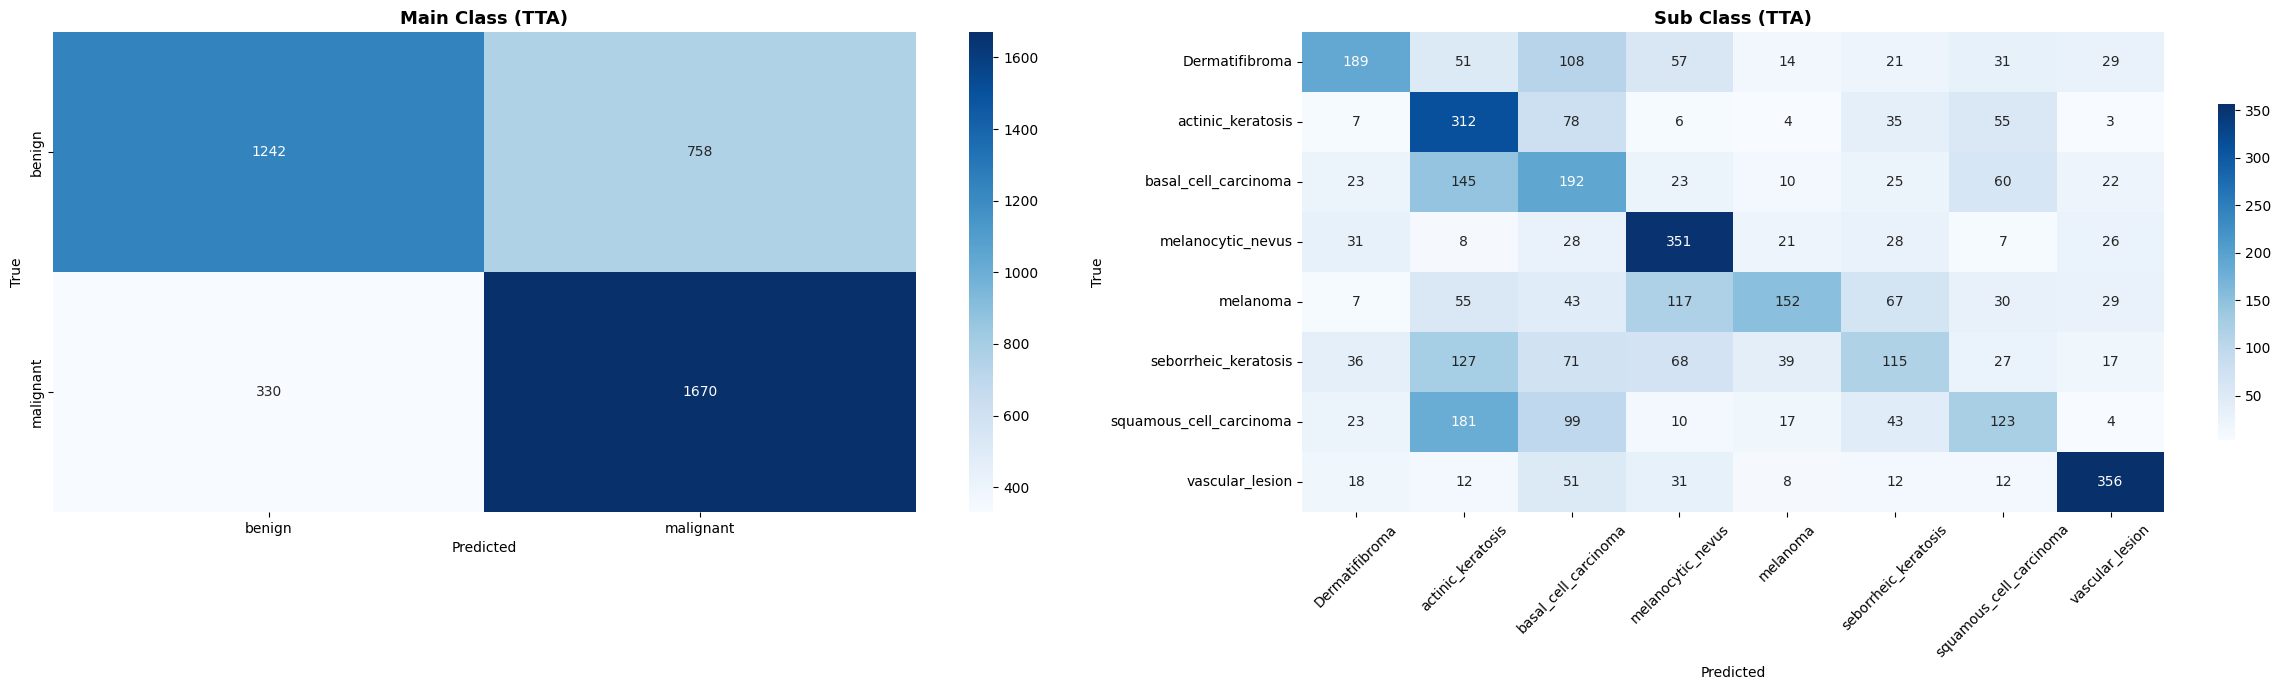

✓ Saved confusion_matrices_v2.png


In [74]:
# ── CONFUSION MATRICES ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8 + 2*NUM_SUB, 7))

cm_main = confusion_matrix(tm_tgts, tm_preds,
                            labels=list(range(NUM_MAIN)))
sns.heatmap(cm_main, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=main_classes, yticklabels=main_classes)
axes[0].set_title('Main Class (TTA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_sub = confusion_matrix(ts_tgts, ts_preds,
                           labels=list(range(NUM_SUB)))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=sub_classes, yticklabels=sub_classes,
            cbar_kws={'shrink': 0.7})
axes[1].set_title('Sub Class (TTA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved confusion_matrices_v2.png")

In [75]:
# ── SINGLE-IMAGE INFERENCE (TTA) ─────────────────────────────────────────────

@torch.no_grad()
def classify_image(image_path, model, device, pipeline=None, n_tta=7):
    """
    Classify a single skin lesion image.

    pipeline=None : direct HC classification (expects pre-cropped 224×224 image)
    pipeline=<obj>: full ARCUNet → SLRC → HC flow on a raw dermoscopy image

    Returns dict: main_class, main_confidence, sub_class, sub_confidence
    """
    model.eval()

    # --- Stage 1+2: optionally run ARCUNet → SLRC ---------------------
    if pipeline is not None:
        roi = pipeline.process_image(
            image_path,
            output_size=(SZ, SZ),
            seg_threshold=CONFIG['seg_threshold'],
            padding=CONFIG['roi_padding'],
            return_intermediate=False)
        pil_img = Image.fromarray(roi.astype('uint8'))
    else:
        try:
            pil_img = Image.open(image_path).convert('RGB')
        except Exception as e:
            return {'error': str(e)}

    # --- Stage 3: HC with TTA -----------------------------------------
    m_sum = s_sum = None
    for ttf in tta_transforms[:n_tta]:
        t = ttf(pil_img).unsqueeze(0).to(device)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            ml, sl = model(t)
        mp = F.softmax(ml, -1).cpu()
        sp = F.softmax(sl, -1).cpu()
        m_sum = mp if m_sum is None else m_sum + mp
        s_sum = sp if s_sum is None else s_sum + sp

    mp_idx = m_sum.argmax(-1).item()
    sp_idx = s_sum.argmax(-1).item()

    return {
        'image_path'      : image_path,
        'main_class'      : idx2main[mp_idx],
        'main_confidence' : f'{(m_sum[0, mp_idx] / n_tta).item():.4f}',
        'sub_class'       : idx2sub[sp_idx],
        'sub_confidence'  : f'{(s_sum[0, sp_idx]  / n_tta).item():.4f}',
        'n_tta'           : n_tta,
        'mode'            : 'pipeline' if pipeline else 'direct',
    }


# Demo on 5 random test samples
print("INFERENCE DEMO (TTA=7)\n" + "="*60)
for _, row in test_df.sample(5, random_state=1).iterrows():
    img_path = os.path.join(CONFIG['data_root'], row['image_path'])
    if not os.path.exists(img_path):
        continue
    res = classify_image(img_path, model, CONFIG['device'],
                         pipeline=pipeline, n_tta=7)
    cm = '✓' if res['main_class'] == row['main_class'] else '✗'
    cs = '✓' if res['sub_class']  == row['sub_class']  else '✗'
    print(f"True : {row['main_class']:12s} → {row['sub_class']}")
    print(f"Pred : {res['main_class']:12s} → {res['sub_class']}  "
          f"[main {cm} {res['main_confidence']}  sub {cs} {res['sub_confidence']}]\n")

print("Usage:")
print("  res = classify_image('/path/to/image.jpg', model, device)")
print("  res = classify_image('/path/to/raw.jpg',   model, device, pipeline=pipeline)")

INFERENCE DEMO (TTA=7)
True : benign       → Dermatifibroma
Pred : benign       → Dermatifibroma  [main ✓ 0.7505  sub ✓ 0.3538]

True : malignant    → basal_cell_carcinoma
Pred : malignant    → seborrheic_keratosis  [main ✓ 0.5200  sub ✗ 0.1829]

True : benign       → Dermatifibroma
Pred : benign       → melanocytic_nevus  [main ✓ 0.6328  sub ✗ 0.2668]

True : malignant    → actinic_keratosis
Pred : malignant    → seborrheic_keratosis  [main ✓ 0.5679  sub ✗ 0.2268]

True : malignant    → actinic_keratosis
Pred : malignant    → actinic_keratosis  [main ✓ 0.6289  sub ✓ 0.2458]

Usage:
  res = classify_image('/path/to/image.jpg', model, device)
  res = classify_image('/path/to/raw.jpg',   model, device, pipeline=pipeline)


## Architecture & Training Summary

### Model: `HierarchicalClassifier`
```
EfficientFormerV2-S2 (pretrained ImageNet)
    ↓ backbone features (288-d)
  SEBlock (channel attention)
    ↓
  main_head: Linear(288→256) → LayerNorm → GELU → Dropout(0.20) → Linear(256→2)
    ↓ main_logits.detach()
  sub_head:  Linear(290→512) → LayerNorm → GELU → Dropout(0.25)
           → Linear(512→256) → LayerNorm → GELU → Dropout(0.15)
           → Linear(256→8)
```

### Key design decisions
| Decision | Rationale |
|---|---|
| Conditional sub-head | Sub-class explicitly sees main-class logits → encodes hierarchy |
| SEBlock in main_head | Channel attention on backbone features at negligible cost |
| Differential LR (backbone ×0.1) | Protects pretrained weights from large gradient updates |
| AsymmetricFocalLoss + alpha | Focal down-weights easy samples; alpha corrects residual imbalance |
| WeightedRandomSampler | Extra guard — ensures each batch is class-balanced |
| MixUp + CutMix (50% of batches) | Strong regularisation, prevents memorising augmentation artefacts |
| AMP + channels_last | ~1.5–2× speed-up on Ampere GPUs, no accuracy cost |
| 7-view TTA at test time | Free accuracy gain by averaging over geometric invariances |

### Checkpoint keys
```python
ckpt = torch.load('checkpoints/hc_best.pt')
model.load_state_dict(ckpt['model_sd'])   # note: key is 'model_sd'
```